# Exploración del dataset Preprocesado

In [1]:
# Vamos a volver a cargar el dataset

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_limpio = pd.read_csv(r"C:\Users\orlan\Documents\Aprendizaje Automatico\TP\perfiles_limpios_2022_2024_15000_80000.csv", 
                 encoding= "ISO-8859-1")

In [2]:
df_limpio.shape

(11041, 653)

In [3]:
n_perfiles = len(df_limpio)
n_alturas = len(df_limpio.columns[3:])

print(f"Perfiles: {n_perfiles}")
print(f"Niveles verticales: {n_alturas}")

Perfiles: 11041
Niveles verticales: 650


In [4]:
# Perfiles por año

df_limpio["fecha"] = pd.to_datetime(df_limpio["fecha"])

perfiles_anio = (
    df_limpio["fecha"]
    .dt.year
    .value_counts()
    .sort_index())

perfiles_anio


fecha
2022    3032
2023    3982
2024    4027
Name: count, dtype: int64

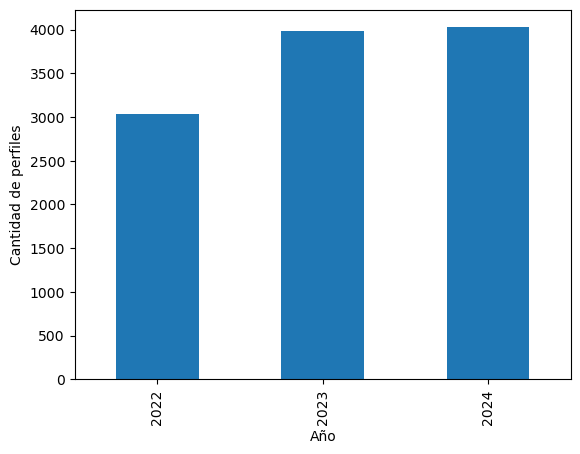

In [5]:
# Vamos a graficar Perfiles por año

perfiles_anio.plot(kind="bar")

plt.ylabel("Cantidad de perfiles")
plt.xlabel("Año")

plt.show()

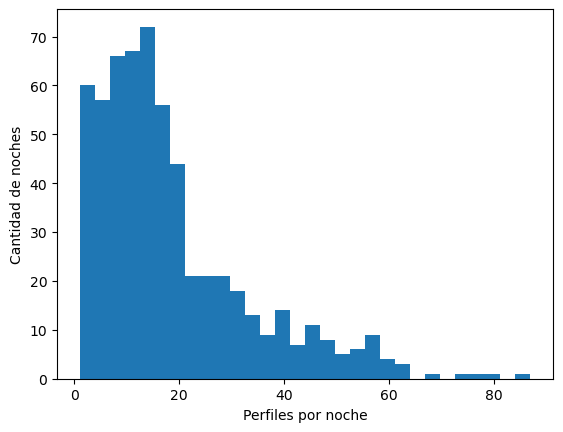

In [6]:
# Vamos a graficar perfiles por noche

perfiles_noche = (
    df_limpio
    .groupby("fecha")
    .size())

plt.hist(
    perfiles_noche,
    bins=30)

plt.xlabel("Perfiles por noche")
plt.ylabel("Cantidad de noches")

plt.show()


In [7]:
perfiles_noche.describe()

count    597.000000
mean      18.494137
std       14.923363
min        1.000000
25%        8.000000
50%       15.000000
75%       24.000000
max       87.000000
dtype: float64

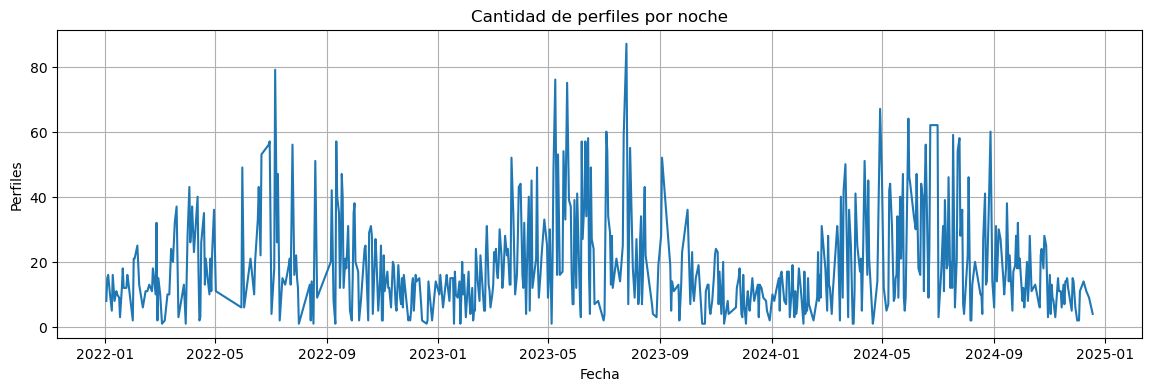

In [8]:
perfiles_por_fecha = (
    df_limpio
    .groupby("fecha")
    .size()
)

plt.figure(figsize=(14,4))

plt.plot(
    perfiles_por_fecha.index,
    perfiles_por_fecha.values
)

plt.xlabel("Fecha")
plt.ylabel("Perfiles")

plt.title(
    "Cantidad de perfiles por noche"
)

plt.grid(True)

plt.show()

A partir del gráfico anterior podemos identificar que hay una estacionalidad de la cantidad de mediciones por noche. Efectivamente, las noches de invierno son más largas y probablemente admiten más mediciones.


In [9]:
# Vamos a analizar los esta estacionalidad con más profundidad

perfiles_por_noche = (
    df_limpio
    .groupby("fecha")
    .size()
)

media_mensual = (
    perfiles_por_noche
    .groupby(perfiles_por_noche.index.month)
    .mean()
)

media_mensual

fecha
1     10.864407
2     12.745098
3     18.872727
4     23.377358
5     27.136364
6     30.738095
7     27.277778
8     18.153846
9     21.019608
10    15.092593
11    10.870370
12     8.121951
dtype: float64

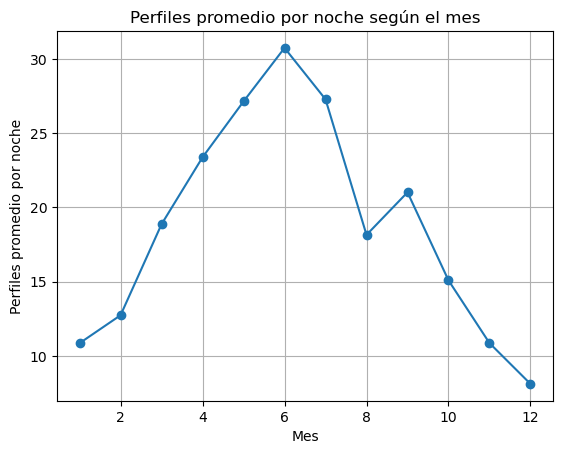

In [10]:
media_mensual.plot(marker="o")

plt.xlabel("Mes")
plt.ylabel("Perfiles promedio por noche")
plt.title("Perfiles promedio por noche según el mes")

plt.grid(True)

plt.show()

Efectivamente este gráfico nos demuestra la alta estacionalidad que mencionamos.


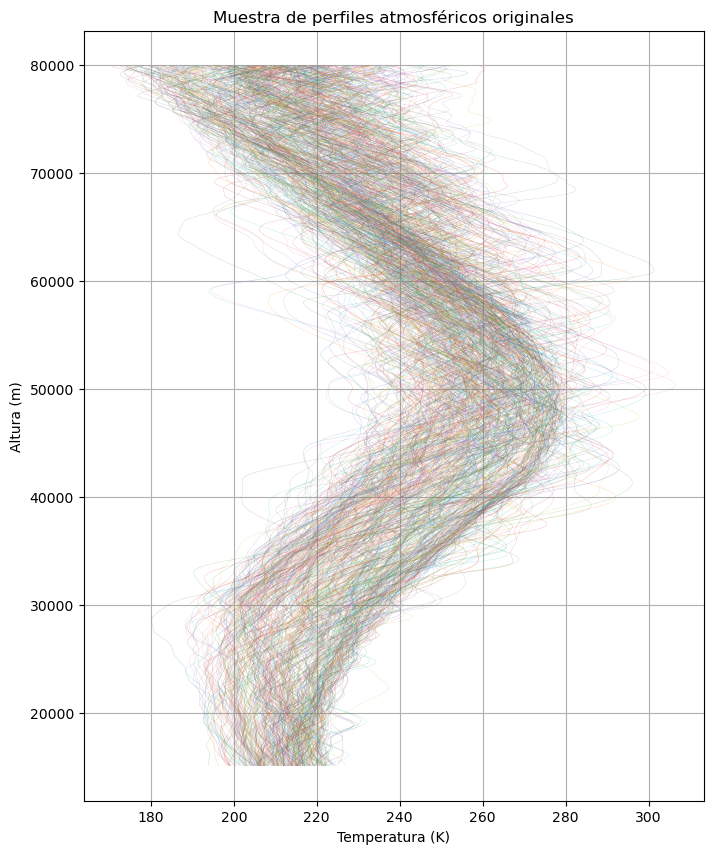

In [15]:
# Nuevamente vamos a graficar un subconjunto de perfiles
# Mostrar la nube completa satura la memoria

# columnas de temperatura
temp_cols = df_limpio.columns[3:]

# alturas
alturas = temp_cols.astype(float)

# muestra aleatoria de perfiles
muestra = df_limpio.sample(
    n=500,
    random_state=42
)

plt.figure(figsize=(8,10))

for _, fila in muestra.iterrows():
    plt.plot(
        fila[temp_cols],
        alturas,
        alpha=0.3,
        linewidth=0.3
    )

plt.xlabel("Temperatura (K)")
plt.ylabel("Altura (m)")
plt.title("Muestra de perfiles atmosféricos originales")

plt.grid(True)

plt.show()

In [17]:
# Vamos a verificar los NaN existentes

# columnas de temperatura
temp_cols = df_limpio.columns[3:]

# cantidad de perfiles 100% completos

perfiles_sin_nan = (
    df_limpio[temp_cols]
    .notna()
    .all(axis=1)
)

print("Perfiles sin NaN:", perfiles_sin_nan.sum())

# Cantidad de perfiles con al menos un NaN

perfiles_con_nan = (
    df_limpio[temp_cols]
    .isna()
    .any(axis=1)
)

print("Perfiles con al menos un NaN:", perfiles_con_nan.sum())
print("Porcentaje:", 100 * perfiles_con_nan.mean())


Perfiles sin NaN: 8541
Perfiles con al menos un NaN: 2500
Porcentaje: 22.642876551037045


In [18]:
# Vamos a ver cómo se distribuyen esos NaN

nan_por_perfil = (
    df_limpio[temp_cols]
    .isna()
    .sum(axis=1)
)

nan_por_perfil.describe()

count    11041.000000
mean        32.438547
std         62.013164
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        324.000000
dtype: float64

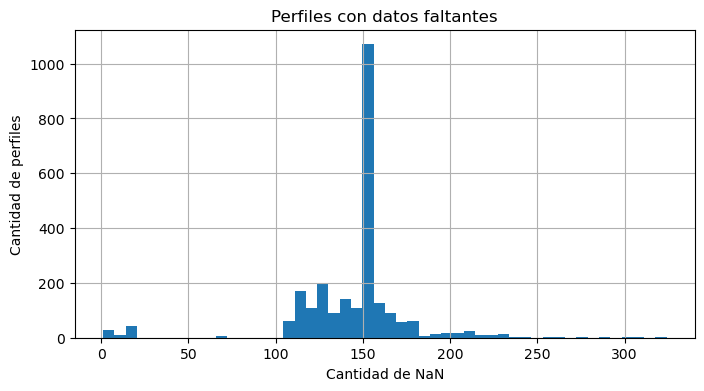

In [20]:
# Vamos a graficar

plt.figure(figsize=(8,4))

plt.hist(
    nan_por_perfil[nan_por_perfil > 0],
    bins=50
)

plt.xlabel("Cantidad de NaN")
plt.ylabel("Cantidad de perfiles")
plt.title("Perfiles con datos faltantes")

plt.grid(True)

plt.show()

In [21]:
print("Más de 10 NaN:", (nan_por_perfil > 10).sum())
print("Más de 50 NaN:", (nan_por_perfil > 50).sum())
print("Más de 100 NaN:", (nan_por_perfil > 100).sum())
print("Más de 200 NaN:", (nan_por_perfil > 200).sum())

Más de 10 NaN: 2471
Más de 50 NaN: 2419
Más de 100 NaN: 2414
Más de 200 NaN: 91


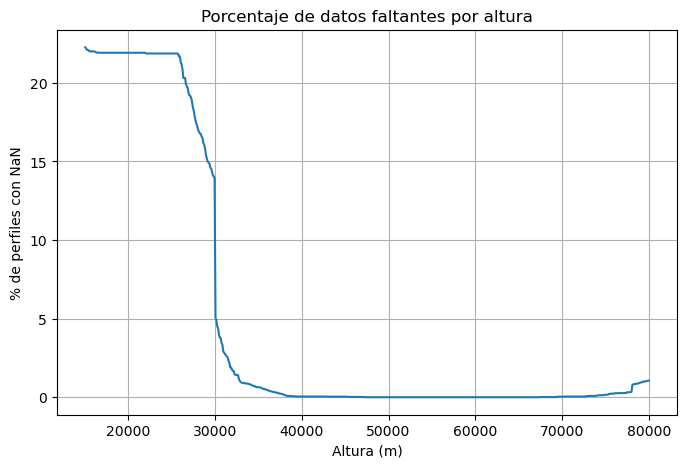

In [22]:
# Vamos a ver el porcentaje de datos faltantes por altura

temp_cols = df_limpio.columns[3:]
alturas = temp_cols.astype(float)

na_por_altura = (
    df_limpio[temp_cols]
    .isna()
    .mean()
)

plt.figure(figsize=(8,5))

plt.plot(
    alturas,
    100 * na_por_altura
)

plt.xlabel("Altura (m)")
plt.ylabel("% de perfiles con NaN")
plt.title("Porcentaje de datos faltantes por altura")

plt.grid(True)

plt.show()

In [26]:
# Vamos a ver cómo seon los 10 perfiles con más NaN

nan_por_perfil = (
    df_limpio[temp_cols]
    .isna()
    .sum(axis=1))

top_nan = nan_por_perfil.nlargest(10)

pd.DataFrame({
    "fecha": df_limpio.loc[top_nan.index, "fecha"],
    "time": df_limpio.loc[top_nan.index, "time"],
    "NaN": top_nan.values
})

,fecha,time,NaN
110,2022-01-17,23049000,324
122,2022-01-19,25449000,318
6964,2023-12-18,24188000,307
914,2022-04-23,25920000,302
915,2022-04-23,26820000,302
6963,2023-12-18,23288000,286
38,2022-01-04,23819000,278
10078,2024-08-30,14602000,264
6280,2023-08-24,27439000,257
6281,2023-08-24,28339000,257


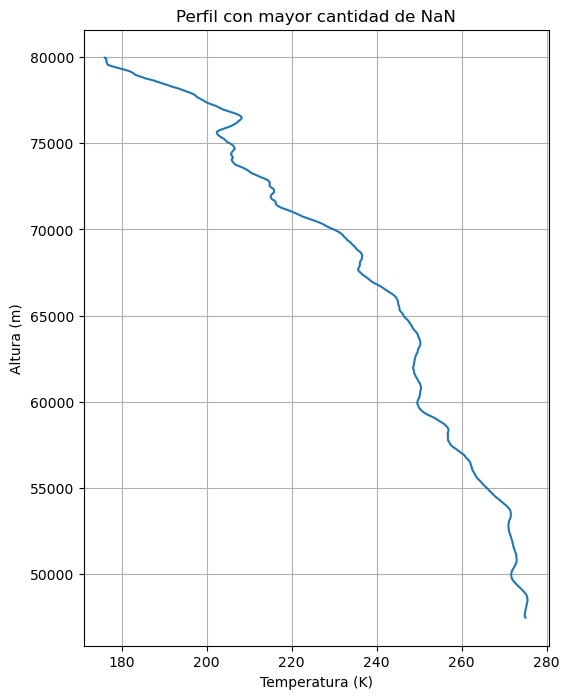

In [27]:
idx_peor = nan_por_perfil.idxmax()

perfil_peor = df_limpio.loc[idx_peor, temp_cols]

perfil_peor.isna().sum()

plt.figure(figsize=(6,8))

plt.plot(
    perfil_peor.values,
    temp_cols.astype(float)
)

plt.xlabel("Temperatura (K)")
plt.ylabel("Altura (m)")
plt.title("Perfil con mayor cantidad de NaN")

plt.grid(True)

plt.show()

In [28]:
perfil_peor.isna()

15068     True
15168     True
15268     True
15368     True
15468     True
         ...  
79568    False
79668    False
79768    False
79868    False
79968    False
Name: 110, Length: 650, dtype: bool

In [29]:
perfil_peor = df_limpio.loc[idx_peor, temp_cols]

alturas_validas = temp_cols[perfil_peor.notna()].astype(float)

print("Primera altura válida:", alturas_validas.min())
print("Última altura válida:", alturas_validas.max())

Primera altura válida: 47468.0
Última altura válida: 79968.0


In [30]:
temp_cols = df_limpio.columns[3:]
alturas = temp_cols.astype(float)

inicio_valido = []

for _, fila in df_limpio[temp_cols].iterrows():

    validas = alturas[fila.notna()]

    inicio_valido.append(validas.min())

inicio_valido = pd.Series(inicio_valido)

inicio_valido.describe()

count    11041.000000
mean     18281.649126
std       6148.866052
min      15068.000000
25%      15068.000000
50%      15068.000000
75%      15068.000000
max      47468.000000
dtype: float64

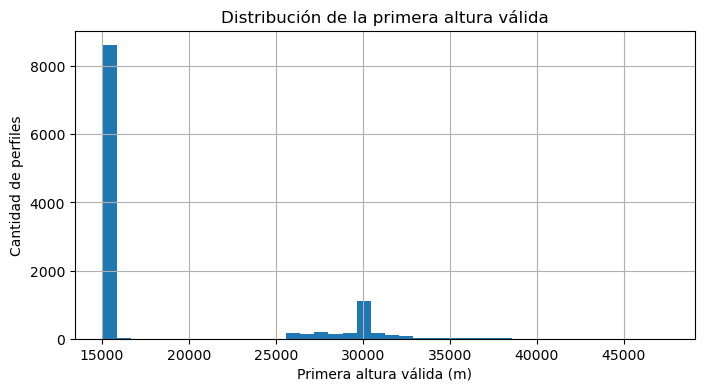

In [31]:
plt.figure(figsize=(8,4))

plt.hist(
    inicio_valido,
    bins=40
)

plt.xlabel("Primera altura válida (m)")
plt.ylabel("Cantidad de perfiles")

plt.title("Distribución de la primera altura válida")

plt.grid(True)

plt.show()

# Perfiles con NaN

Encontramos que hay +20% de perfiles con algún NaN. Esto puede traer problemas para la aplicación de algoritmos de clustering. Alrededor de 8500 perfiles arrancan desde 15 k m, la grán mayoría del resto arranca alrededor de los 30 k m. 
Según lo mencionado por el especialista, hay una justificación, este comportamiento es consistente con el mecanismo de control de calidad aplicado durante el procesamiento de los datos, que descarta observaciones de baja confiabilidad en las capas inferiores de la atmósfera.
Ante esta situación aparecen las siguientes opciones, eliminar los perfiles con NaN (23%), o imputar NaN con alguno o algunos metodos. Descartamos la opción de recortar el rango vertical.
Lo que vamos a hacer es avanzar con varios dataset en paralelo: uno eliminando los que tienen NaN, y otros imputando valores de una u otra forma, y luego comparar los clusters que obtengamos de cada uno. A su vez los compararemos con los perfiles propuestos por el informe original.


In [32]:
# Vamos a seguir explorando los datos del dataset

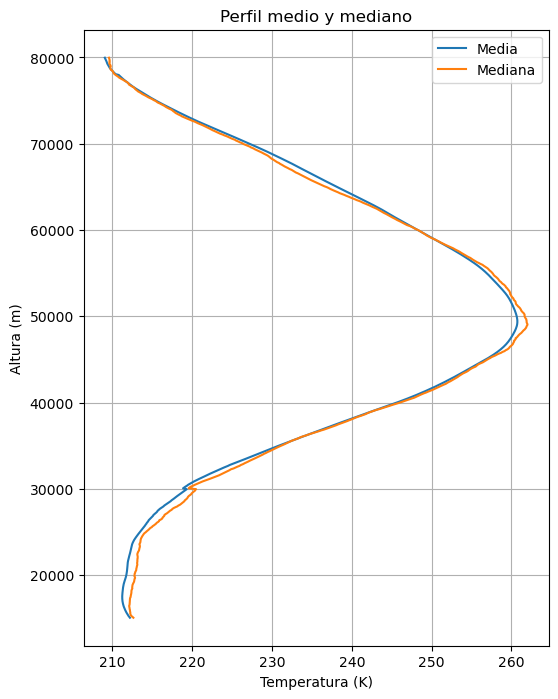

In [34]:
# Vamos a trazar los perfiles medio y mediano

temp_cols = df_limpio.columns[3:]

alturas = temp_cols.astype(float)

perfil_medio = (
    df_limpio[temp_cols]
    .mean())

perfil_mediano = (
    df_limpio[temp_cols]
    .median())

plt.figure(figsize=(6,8))

plt.plot(
    perfil_medio,
    alturas,
    label="Media"
)

plt.plot(
    perfil_mediano,
    alturas,
    label="Mediana"
)

plt.xlabel("Temperatura (K)")
plt.ylabel("Altura (m)")
plt.title("Perfil medio y mediano")

plt.legend()
plt.grid(True)
plt.grid(True)

plt.show()

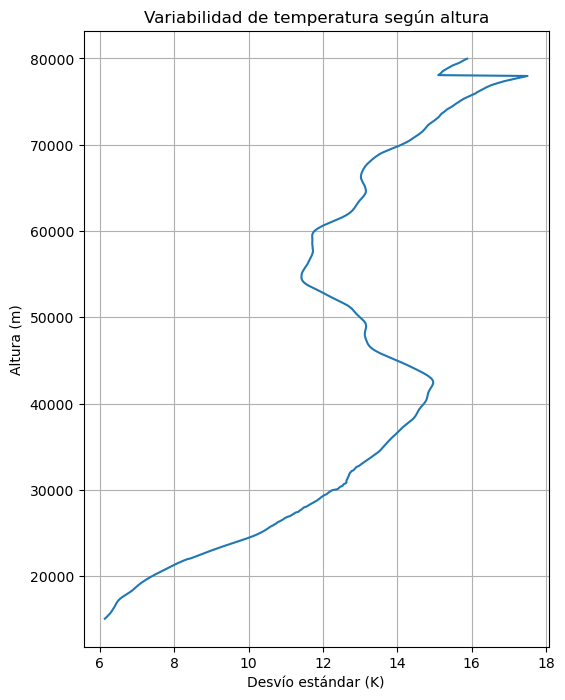

In [35]:
# Vamos a trazar la dispersión en función de la altura

perfil_std = (
    df_limpio[temp_cols]
    .std()
)

plt.figure(figsize=(6,8))

plt.plot(
    perfil_std,
    alturas
)

plt.xlabel("Desvío estándar (K)")
plt.ylabel("Altura (m)")
plt.title("Variabilidad de temperatura según altura")

plt.grid(True)

plt.show()



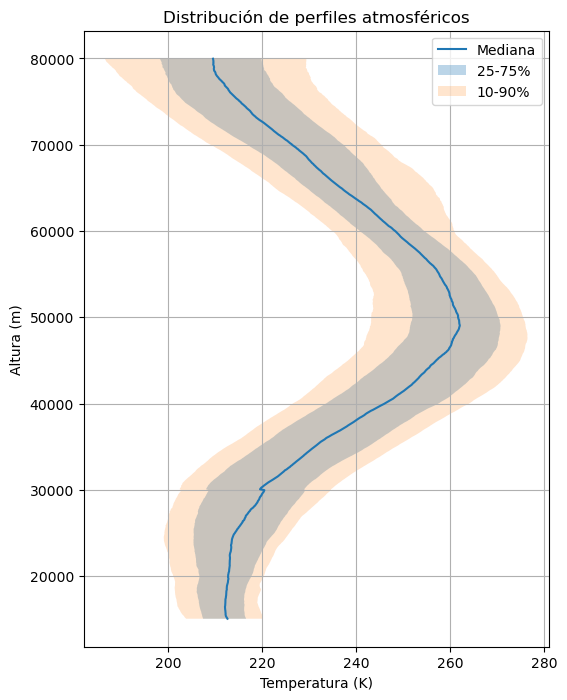

In [39]:
# Vamos a ver los percentiles

p10 = df_limpio[temp_cols].quantile(0.10)
p25 = df_limpio[temp_cols].quantile(0.25)
p75 = df_limpio[temp_cols].quantile(0.75)
p90 = df_limpio[temp_cols].quantile(0.90)

plt.figure(figsize=(6,8))

plt.plot(perfil_mediano, alturas, label="Mediana")

plt.fill_betweenx(
    alturas,
    p25,
    p75,
    alpha=0.3,
    label="25-75%"
)

plt.fill_betweenx(
    alturas,
    p10,
    p90,
    alpha=0.2,
    label="10-90%"
)

plt.xlabel("Temperatura (K)")
plt.ylabel("Altura (m)")
plt.title("Distribución de perfiles atmosféricos")

plt.legend()
plt.grid(True)

plt.show()

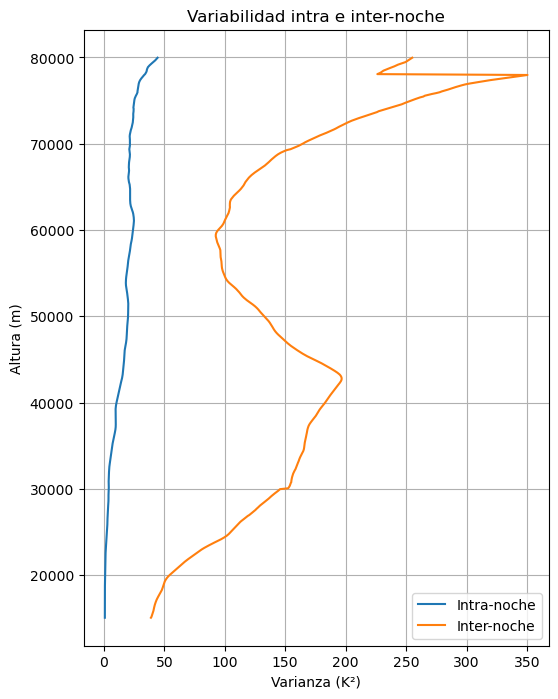

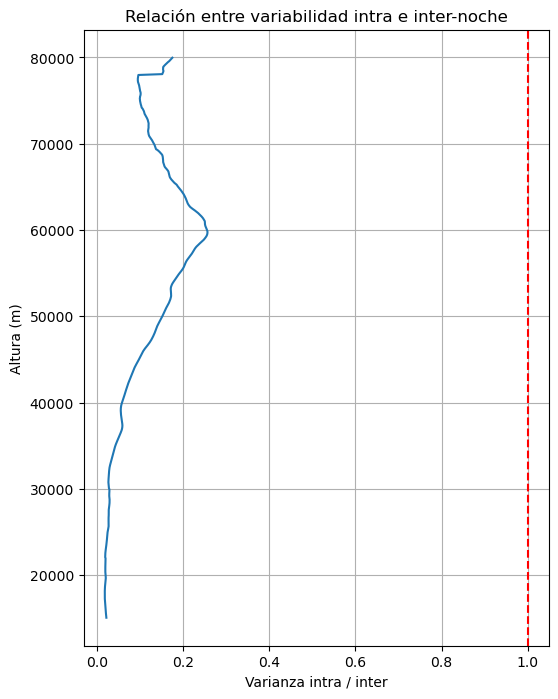

In [43]:
# Vamos a armar el perfil medio, mediano y variabilidad dentro de cada noche
# Graficamos

# columnas de temperatura
temp_cols = df_limpio.columns[3:]

# perfil medio por noche
perfil_medio_noche = (
    df_limpio
    .groupby("fecha")[temp_cols]
    .mean())

perfil_medio_noche.shape

# perfil mediono por noche
perfil_mediano_noche = (
    df_limpio
    .groupby("fecha")[temp_cols]
    .median())

# variabilidad intra noche
var_intra_noche = (
    df_limpio
    .groupby("fecha")[temp_cols]
    .var())

# Variabilidad intra-noche promedio
var_intra_media = var_intra_noche.mean()

# Variabilidad inter-noche
var_inter = perfil_medio_noche.var()


# Graficamos

alturas = temp_cols.astype(float)

plt.figure(figsize=(6,8))

plt.plot(
    var_intra_media,
    alturas,
    label="Intra-noche"
)

plt.plot(
    var_inter,
    alturas,
    label="Inter-noche"
)

plt.xlabel("Varianza (K²)")
plt.ylabel("Altura (m)")
plt.title("Variabilidad intra e inter-noche")

plt.legend()
plt.grid(True)

plt.show()

# Relación intra/inter

ratio = var_intra_media / var_inter

plt.figure(figsize=(6,8))

plt.plot(
    ratio,
    alturas
)

plt.axvline(
    1,
    color="red",
    linestyle="--"
)

plt.xlabel("Varianza intra / inter")
plt.ylabel("Altura (m)")
plt.title("Relación entre variabilidad intra e inter-noche")

plt.grid(True)

plt.show()


In [45]:
perfiles_por_noche = (
    df_limpio
    .groupby("fecha")
    .size()
)

perfiles_por_noche.describe()


count    597.000000
mean      18.494137
std       14.923363
min        1.000000
25%        8.000000
50%       15.000000
75%       24.000000
max       87.000000
dtype: float64

In [46]:
(perfiles_por_noche == 1).sum()

np.int64(17)